16:26:13 - cmdstanpy - INFO - Chain [1] start processing
16:26:13 - cmdstanpy - INFO - Chain [1] done processing
Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.



 Metrics: {'MAE_test': 0.8116533346475241, 'RMSE_test': 1.0141252494523256, 'horizon_days': 30, 'train_size': 335, 'test_size': 30, 'CV_mae_mean': 1.3223933479686818, 'CV_rmse_mean': 1.5844559096741289, 'CV_folds': 3}


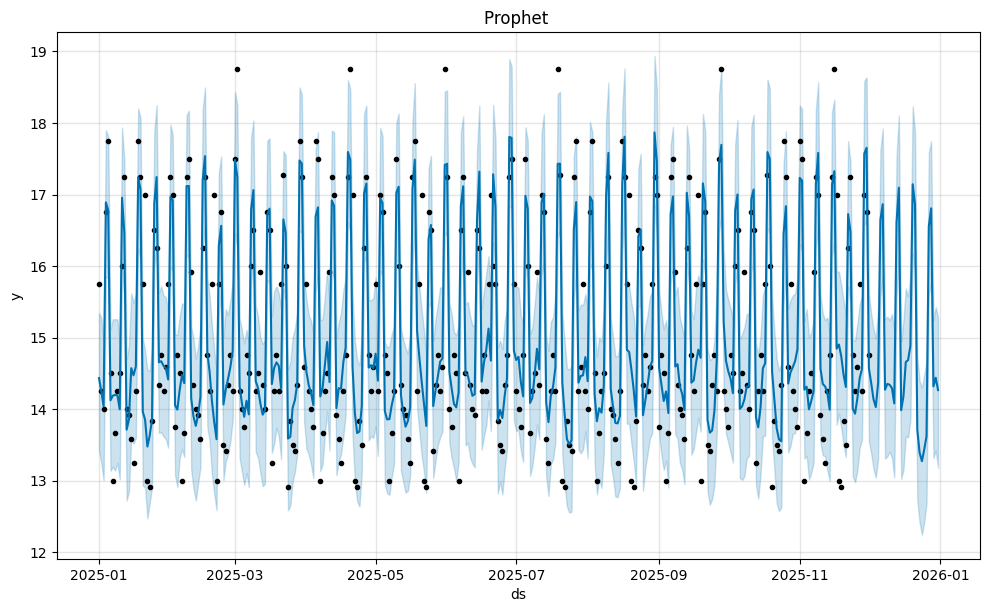

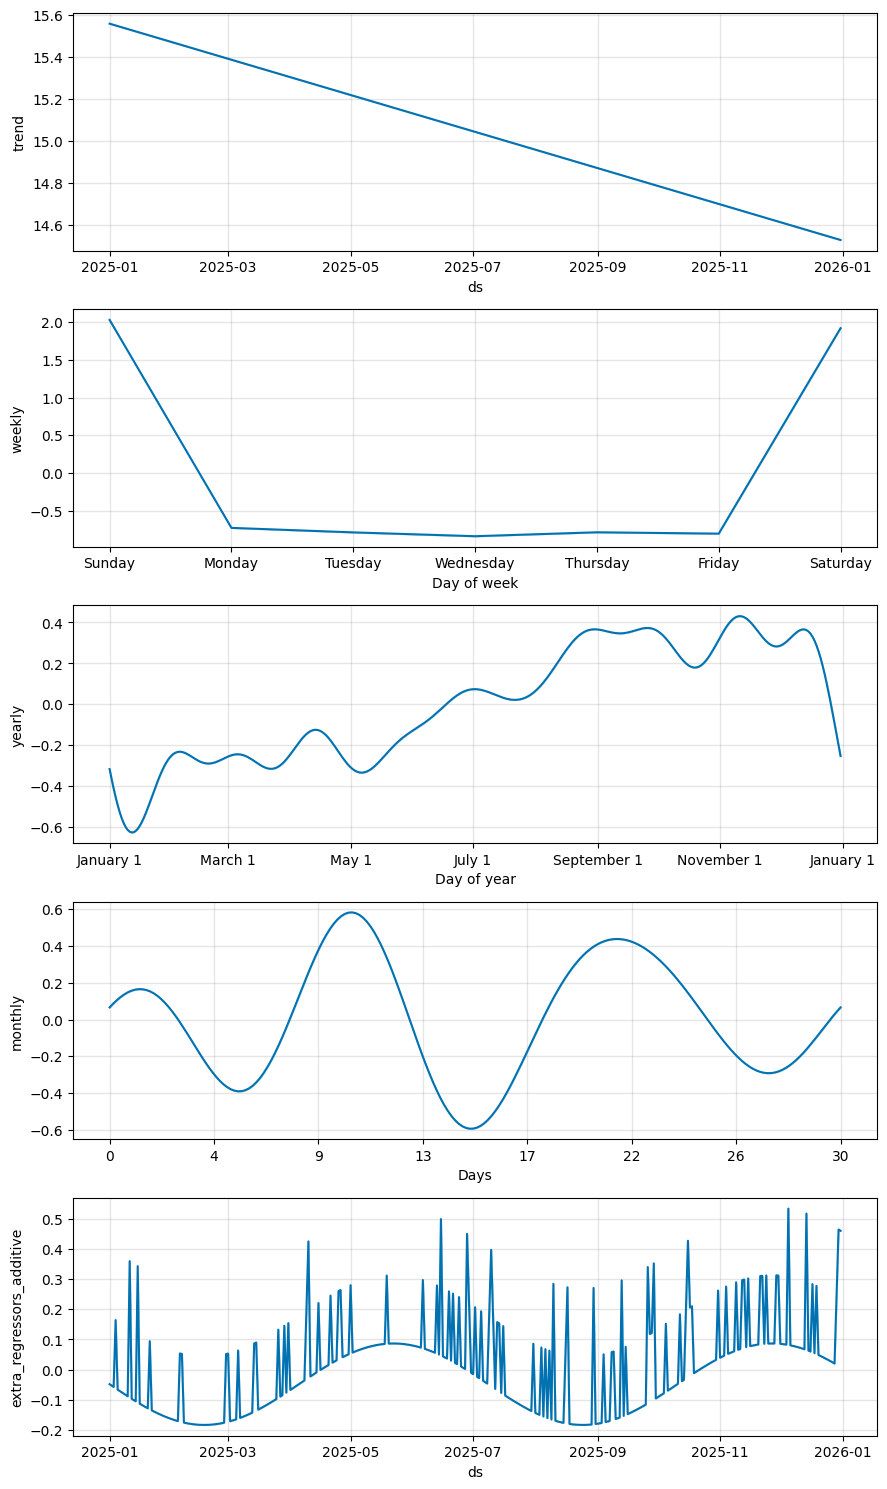

Forecast sauvegardé : c:\Users\nzime\OneDrive\Documents\Prediction_de_vente\models\artifacts\prophet_forecast_final.csv
Metrics sauvegardées : c:\Users\nzime\OneDrive\Documents\Prediction_de_vente\models\metrics\prophet_metrics_final.json


In [10]:
import pandas as pd
from pathlib import Path
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import json

PROJECT_ROOT = Path.cwd().parent
CLEAN_PATH = PROJECT_ROOT / "data" / "interim" / "sample_clean.csv"

FORECAST_PATH = PROJECT_ROOT / "models" / "artifacts" / "prophet_forecast_final.csv"
METRICS_PATH = PROJECT_ROOT / "models" / "metrics" / "prophet_metrics_final.json"

FORECAST_PATH.parent.mkdir(parents=True, exist_ok=True)
METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(CLEAN_PATH, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
df_prophet = df.rename(columns={"date": "ds", "value": "y"})

# Handle duplicate dates
df_prophet = df_prophet.groupby("ds", as_index=False).agg({"y": "mean"})

# Enforce daily frequency
df_prophet = df_prophet.set_index("ds").asfreq("D").interpolate().reset_index()
assert df_prophet["ds"].is_unique


# Adding regressors

np.random.seed(42)
df_prophet['price'] = 100 + 5 * np.sin(np.arange(len(df_prophet))/30) + np.random.normal(0, 2, len(df_prophet))
df_prophet['marketing_spend'] = np.random.choice([0,50,100], size=len(df_prophet), p=[0.8,0.15,0.05])

# Train/Test split

horizon = 30
train_df = df_prophet.iloc[:-horizon]
test_df = df_prophet.iloc[-horizon:]

# Prophet 
model = Prophet(
    growth="linear",
    weekly_seasonality=False,
    yearly_seasonality=False,
    changepoint_prior_scale=0.03,
    seasonality_prior_scale=5.0
)

# Seasonality
model.add_seasonality("weekly", period=7, fourier_order=5)
model.add_seasonality("monthly", period=30.5, fourier_order=5)
model.add_seasonality("yearly", period=365.25, fourier_order=10)

# Regressors
model.add_regressor('price')
model.add_regressor('marketing_spend')

# Fit
model.fit(train_df)

# Future DataFrame
future = model.make_future_dataframe(periods=horizon, freq="D")
future['price'] = 100 + 5 * np.sin(np.arange(len(future))/30)
future['marketing_spend'] = np.random.choice([0,50,100], size=len(future), p=[0.8,0.15,0.05])

forecast = model.predict(future)

# Evaluation TEST

eval_df = test_df.merge(forecast[['ds','yhat']], on='ds', how='inner')
y_true = eval_df['y']
y_pred = eval_df['yhat']

mae_test = mean_absolute_error(y_true, y_pred)
rmse_test = np.sqrt(mean_squared_error(y_true, y_pred))

metrics = {
    "MAE_test": float(mae_test),
    "RMSE_test": float(rmse_test),
    "horizon_days": horizon,
    "train_size": len(train_df),
    "test_size": len(test_df)
}

# Cross-validation dynamique

n_days = (df_prophet['ds'].max() - df_prophet['ds'].min()).days
initial_days = int(n_days * 0.6)
period_days = max(int(n_days * 0.1), horizon)

df_cv = cross_validation(
    model,
    initial=f"{initial_days} days",
    period=f"{period_days} days",
    horizon=f"{horizon} days",
    parallel="processes"
)

df_perf = performance_metrics(df_cv)

metrics["CV_mae_mean"] = float(df_perf["mae"].mean())
metrics["CV_rmse_mean"] = float(df_perf["rmse"].mean())
metrics["CV_folds"] = int(df_cv["cutoff"].nunique())

print("\n Metrics:", metrics)

# Plots

model.plot(forecast)
plt.title("Prophet ")
plt.show()

model.plot_components(forecast)
plt.show()

forecast.to_csv(FORECAST_PATH, index=False)
with open(METRICS_PATH, 'w') as f:
    json.dump(metrics, f, indent=2)

print(f"Forecast sauvegardé : {FORECAST_PATH}")
print(f"Metrics sauvegardées : {METRICS_PATH}")
